In [1]:
!pip install -Uq numpy

In [2]:
!pip install -Uq matplotlib

In [3]:
!pip install -Uq pymcel

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import copy

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### Sistema inicial: Sol, Tierra y Apophis

Se realizó inicialmente la simulación considerando un sistema compuesto por el Sol, la Tierra y Apophis para después considerar más planetas, el proceso se hizo por el método de leapfrog visto en clase.

In [5]:
# Definición del sistema: Sol fijo, Tierra y Apophis
sistema_apophis = [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=1e-10, r=np.array([0.8, 0.0, 0.0]), v=np.array([0.0, 1.2, 0.0])), # Apophis
]

In [6]:
def aceleraciones(sistema_apophis):
    n = len(sistema_apophis)
    a = [np.zeros(3) for _ in range(n)]
    
    for i in range(n):
        if i == 0:  # Sol fijo, no recibe aceleraciones
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema_apophis[j]['r'] - sistema_apophis[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema_apophis[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

In [7]:
def paso_leapfrog(sistema_apophis, dt):
    a = aceleraciones(sistema_apophis)
    for i in range(1, len(sistema_apophis)): 
        sistema_apophis[i]['v'] += 0.5 * a[i] * dt

    for i in range(1, len(sistema_apophis)):  # No mover Sol
        sistema_apophis[i]['r'] += sistema_apophis[i]['v'] * dt

    a_new = aceleraciones(sistema_apophis)
    for i in range(1, len(sistema_apophis)):  
        sistema_apophis[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.001
pasos = 20000

trayectorias = [[] for _ in sistema_apophis]

for _ in range(pasos):
    paso_leapfrog(sistema_apophis, dt)
    for i in range(len(sistema_apophis)):
        trayectorias[i].append(sistema_apophis[i]['r'].copy())


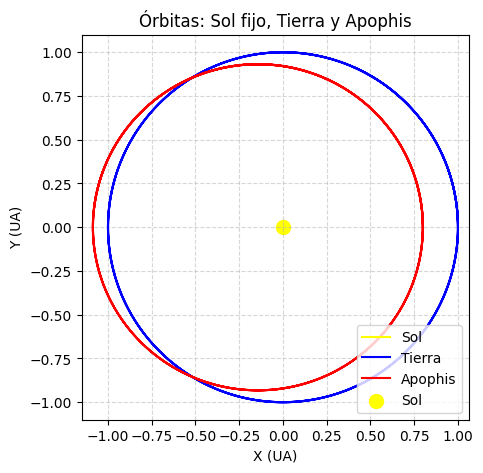

In [11]:
colors = ['yellow', 'blue', 'red']
labels = ['Sol', 'Tierra', 'Apophis']

# Gráfica
plt.figure(figsize=(5,5))
for i in range(len(sistema_apophis)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i])
    # 👇 Quitamos el scatter de la última posición
    # plt.scatter(tray[-1,0], tray[-1,1], color=colors[i], s=50)

plt.scatter(0, 0, color='yellow', s=100, label='Sol')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra y Apophis')
plt.show()


In [12]:
sistema_leap = sistema_apophis
sistema_ref  = copy.deepcopy(sistema_apophis)

ts = np.linspace(0, 10, 1000)

# referencia
rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema_ref, ts)

con n cuerpos solucion

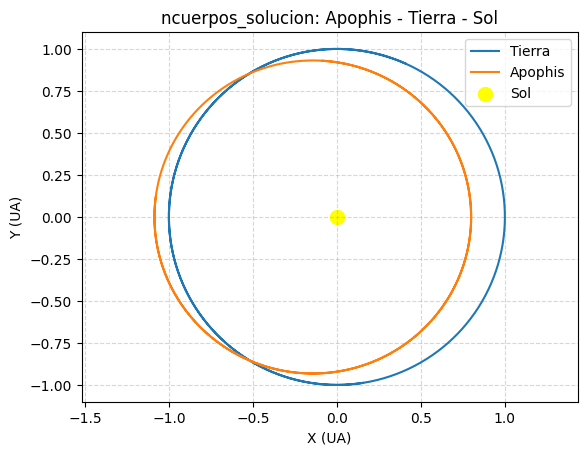

In [13]:
for i in range(len(sistema_ref)):
    tray = rs[i]
    
    if labels[i] != 'Sol':
        plt.plot(tray[:,0], tray[:,1], label=labels[i])
    else:
        plt.plot(tray[:,0], tray[:,1], color='blue') 
        
plt.scatter(0, 0, color='yellow', s=100, label='Sol')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title("ncuerpos_solucion: Apophis - Tierra - Sol")
plt.axis('equal')
plt.show()

### venus,mercurio,marte 


In [14]:
sistema_internos = [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=1e-10, r=np.array([0.8, 0.0, 0.0]), v=np.array([0.0, 1.2, 0.0])), # Apophis
    dict(m=2.4e-6,r=np.array([0.72, 0.0, 0.0]),v=np.array([0.0, 1.18, 0.0])), #Venus
    dict(m=1.7e-7,r=np.array([0.39, 0.0, 0.0]),v=np.array([0.0, 1.6, 0.0])) #Mercurio
]

In [15]:
def aceleraciones(sistema_internos):
    n = len(sistema_internos)
    a = [np.zeros(3) for _ in range(n)]
    
    for i in range(n):
        if i == 0:  # Sol fijo, no recibe aceleraciones
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema_internos[j]['r'] - sistema_internos[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema_internos[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

In [16]:
def paso_leapfrog(sistema_internos, dt):
    a = aceleraciones(sistema_internos)
    for i in range(1, len(sistema_internos)): 
        sistema_internos[i]['v'] += 0.5 * a[i] * dt

    for i in range(1, len(sistema_internos)):  # No mover Sol
        sistema_internos[i]['r'] += sistema_internos[i]['v'] * dt

    a_new = aceleraciones(sistema_internos)
    for i in range(1, len(sistema_internos)):  
        sistema_internos[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.0002
pasos = 70000

trayectorias = [[] for _ in sistema_internos]

for _ in range(pasos):
    paso_leapfrog(sistema_internos, dt)
    for i in range(len(sistema_internos)):
        trayectorias[i].append(sistema_internos[i]['r'].copy())

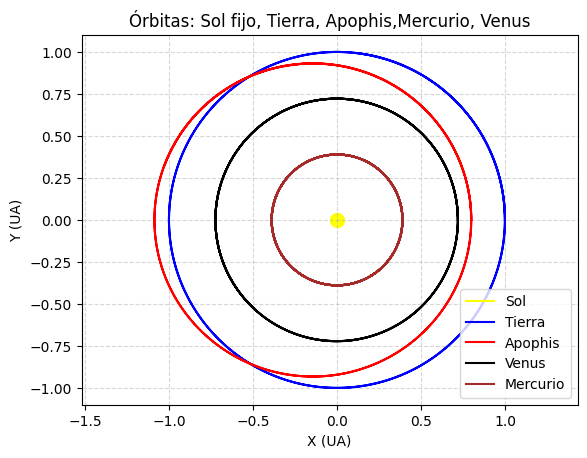

In [17]:
colors = ['yellow', 'blue', 'red', 'black','brown']
labels = ['Sol', 'Tierra', 'Apophis', 'Venus', 'Mercurio']

for i in range(len(sistema_internos)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i])
   

plt.scatter(0, 0, color='yellow', s=100)  # Sol destacado en el origen
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra, Apophis,Mercurio, Venus')
plt.show()


In [18]:
sistema_leap = sistema_internos
sistema_ref  = copy.deepcopy(sistema_internos)

ts = np.linspace(0, 10, 1000)

# referencia
rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema_ref, ts)

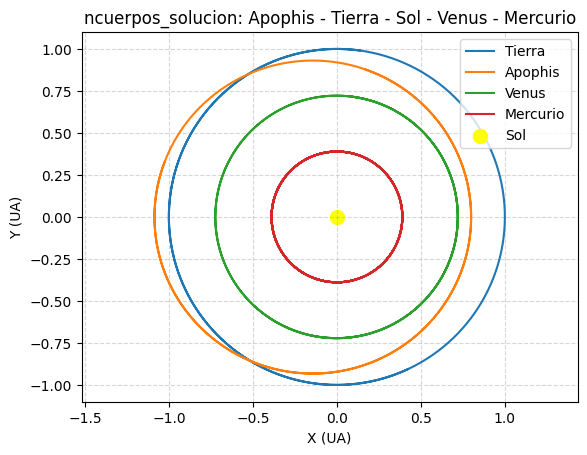

In [19]:
for i in range(len(sistema_ref)):
    tray = rs[i]
    
    if labels[i] != 'Sol':
        plt.plot(tray[:,0], tray[:,1], label=labels[i])
    else:
        plt.plot(tray[:,0], tray[:,1], color='blue') 
        
plt.scatter(0, 0, color='yellow', s=100, label='Sol')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title("ncuerpos_solucion: Apophis - Tierra - Sol - Venus - Mercurio")
plt.axis('equal')
plt.show()

### Inclusión de Júpiter y efectos gravitacionales dominantes

Finalmente, se añadió Júpiter al sistema, cuyo gran tamaño y masa lo convierten en el principal perturbador gravitacional entre los demás planetas.

In [20]:
# Sistema con Sol, Tierra, Apophis, Marte, Venus, Mercurio y Júpiter
sistema= [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=1e-10, r=np.array([0.8, 0.0, 0.0]), v=np.array([0.0, 1.2, 0.0])), # Apophis
    dict(m=3.2e-7, r=np.array([1.52, 0.0, 0.0]), v=np.array([0.0, 0.81, 0.0])), # Marte
    dict(m=2.4e-6, r=np.array([0.72, 0.0, 0.0]), v=np.array([0.0, 1.18, 0.0])), # Venus
    dict(m=1.7e-7, r=np.array([0.39, 0.0, 0.0]), v=np.array([0.0, 1.6, 0.0])), # Mercurio
    dict(m=9.5e-4, r=np.array([5.2, 0.0, 0.0]), v=np.array([0.0, 0.43, 0.0]))  # Júpiter
]

In [37]:
sistema_ref  = copy.deepcopy(sistema)

ts = np.linspace(0, 100, 10000)

# referencia
rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema_ref, ts)

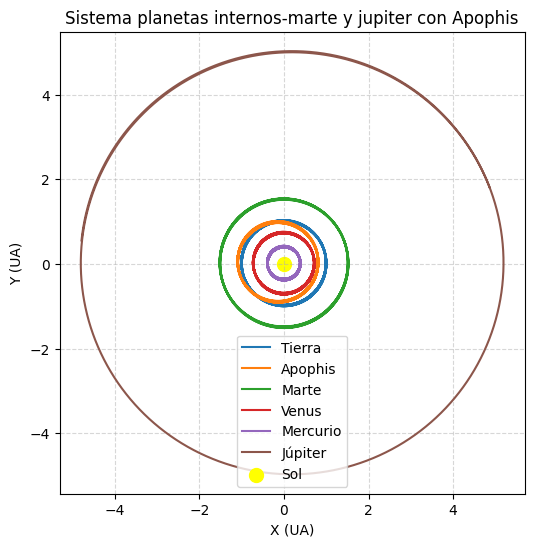

In [38]:
# Gráfica
plt.figure(figsize=(6,6))

for i in range(len(sistema_ref)):
    tray = rs[i]
    
    if labels[i] != 'Sol':
        plt.plot(tray[:,0], tray[:,1], label=labels[i])

# Sol
plt.scatter(0, 0, color='yellow', s=100, label='Sol')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title("Sistema planetas internos-marte y jupiter con Apophis")
plt.axis('equal')
plt.show()

In [35]:
# Sistema con Sol, Tierra, Apophis, Marte, Venus, Mercurio y Júpiter
sistema_completos= [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=1e-10, r=np.array([0.8, 0.0, 0.0]), v=np.array([0.0, 1.2, 0.0])), # Apophis
    dict(m=3.2e-7, r=np.array([1.52, 0.0, 0.0]), v=np.array([0.0, 0.81, 0.0])), # Marte
    dict(m=2.4e-6, r=np.array([0.72, 0.0, 0.0]), v=np.array([0.0, 1.18, 0.0])), # Venus
    dict(m=1.7e-7, r=np.array([0.39, 0.0, 0.0]), v=np.array([0.0, 1.6, 0.0])), # Mercurio
    dict(m=9.5e-4, r=np.array([5.2, 0.0, 0.0]), v=np.array([0.0, 0.43, 0.0])),  # Júpiter
    dict(m=2.86e-4, r=np.array([9.58, 0.0, 0.0]), v=np.array([0.0, 0.322, 0.0])),  # Saturno
    dict(m=4.37e-5, r=np.array([19.2, 0.0, 0.0]), v=np.array([0.0, 0.228, 0.0])),  # Urano
    dict(m=5.15e-5, r=np.array([30.05, 0.0, 0.0]), v=np.array([0.0, 0.182, 0.0]))  # Neptuno
]

In [40]:
sistema_ref  = copy.deepcopy(sistema_completos)

ts = np.linspace(0, 1000, 50000)

# referencia
rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema_ref, ts)

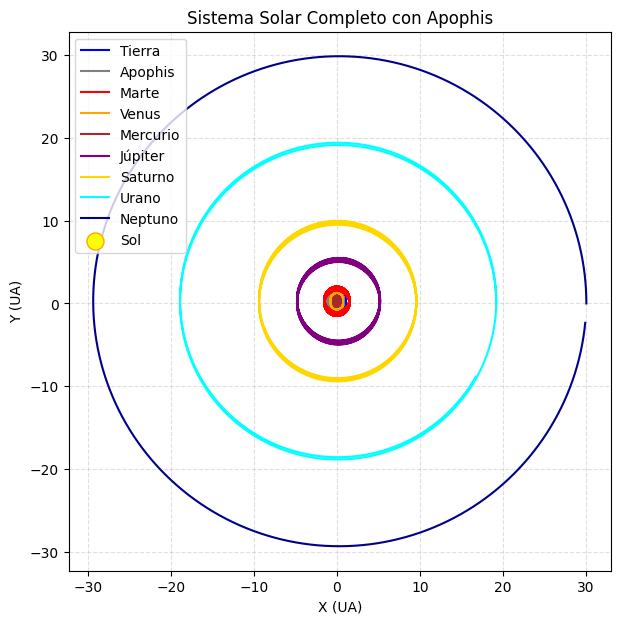

In [41]:
labels = ['Sol', 'Tierra', 'Apophis', 'Marte', 'Venus', 'Mercurio',
          'Júpiter', 'Saturno', 'Urano', 'Neptuno']

colors = ['yellow','blue','gray','red','orange','brown',
          'purple','gold','cyan','darkblue']

plt.figure(figsize=(7,7))

for i in range(len(sistema_ref)):
    tray = rs[i]
    
    if labels[i] != 'Sol':
        plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i])

# Sol
plt.scatter(0, 0, color='yellow', s=150, edgecolor='orange', label='Sol')

# Detalles visuales
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title("Sistema Solar Completo con Apophis")
plt.axis('equal')
plt.tight_layout
plt.show()